# Stock Price Prediction Analysis

This notebook demonstrates the complete workflow for stock price prediction using LSTM and GRU neural networks.

## Table of Contents
1. [Setup and Imports](#Setup-and-Imports)
2. [Data Loading and Exploration](#Data-Loading-and-Exploration)
3. [Data Preprocessing](#Data-Preprocessing)
4. [Model Building](#Model-Building)
5. [Training](#Training)
6. [Evaluation](#Evaluation)
7. [Comparison](#Comparison)

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')


## Data Loading and Exploration

In [2]:
# Adani Ports ticker symbol on NSE (National Stock Exchange of India)
ticker = "ADANIPORTS.NS"

# Define date range
start_date = "2021-03-28"
end_date = "2026-03-28"  # Note: Will only return data up to today

# Download the data
df = yf.download(ticker, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [3]:
# Flatten MultiIndex columns to single level
df.columns = ['_'.join(col).strip() for col in df.columns.values]
df.reset_index(inplace=True)

In [4]:
# Rename columns for easier access
df.rename(columns={
    'Close_ADANIPORTS.NS': 'Close',
    'Open_ADANIPORTS.NS': 'Open', 
    'High_ADANIPORTS.NS': 'High',
    'Low_ADANIPORTS.NS': 'Low',
    'Volume_ADANIPORTS.NS': 'Volume'
}, inplace=True)

In [5]:
# Basic statistics
df.describe()

,Date,Close,High,Low,Open,Volume
count,1236,1236.000000,1236.000000,1236.000000,1236.000000,1.236000e+03
mean,2023-09-27 18:23:18.058252288,1017.986080,1033.057941,1004.147551,1019.900044,6.444519e+06
min,2021-03-30 00:00:00,455.184814,499.034926,388.892904,451.789016,0.000000e+00
25%,2022-06-27 18:00:00,727.237991,736.853042,718.605363,728.197647,2.258730e+06
50%,2023-09-25 12:00:00,858.989685,874.246198,845.399029,859.038928,3.710298e+06
75%,2024-12-30 06:00:00,1354.515778,1372.454487,1334.044864,1354.151770,6.655277e+06
max,2026-03-27 00:00:00,1582.451172,1606.656410,1560.905968,1575.900024,1.155175e+08
std,NaN,316.754663,318.869137,314.626066,317.169818,9.400372e+06


In [6]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values!")

Missing values per column:
No missing values!


In [7]:
pd.DataFrame({"missing_value":df.isna().sum(),"Data_type":df.dtypes})

,missing_value,Data_type
Date,0,datetime64[ns]
Close,0,float64
High,0,float64
Low,0,float64
Open,0,float64
Volume,0,int64


In [8]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [9]:
# # df[['Date', 'Close', 'High', 'Low', 'Open', 'Volume']].astype(float)

# def convert_volume(val):
#     if isinstance(val, str):
#         # Remove any commas first
#         val = val.replace(',', '')
        
#         # Check for Million suffix
#         if 'M' in val:
#             return float(val.replace('M', '')) * 1_000_000
#         # Check for Thousand suffix
#         elif 'K' in val:
#             return float(val.replace('K', '')) * 1_000
#         # Just a number
#         else:
#             return float(val)
#     return val

# df['Vol.'] = df['Vol.'].apply(convert_volume)

In [10]:
# columns_convert=['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
# for col in columns_convert:
#     df[col]=df[col].str.replace(",","").astype(float)

In [11]:
df.to_csv(r"../data/Adani_port_stock.csv",sep=",")

OSError: Cannot save file into a non-existent directory: '../data'

In [12]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2021-03-30,689.743225,696.975081,676.881220,682.462845,9109273
1,2021-03-31,681.831909,698.819463,678.143136,684.355751,7752226
2,2021-04-01,714.690613,720.272237,684.355697,692.606794,15017049
3,2021-04-05,720.514954,723.184426,694.062906,710.322421,15622924
4,2021-04-06,811.082825,827.730650,721.242951,733.862276,64555516


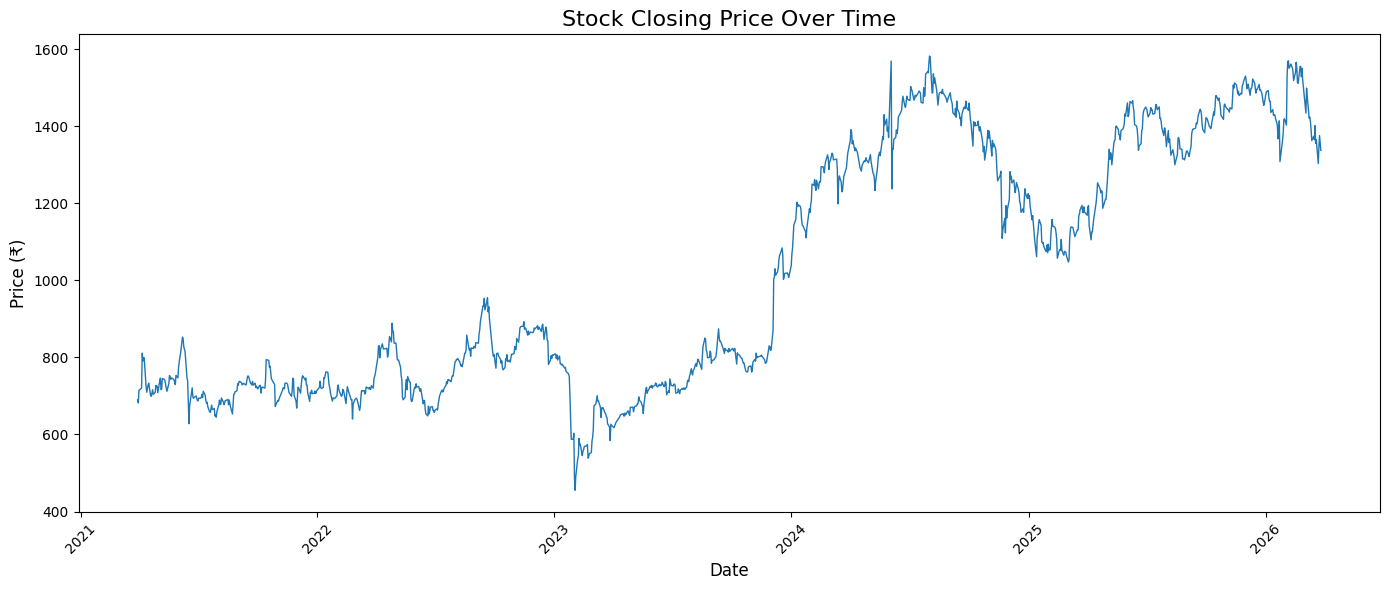

In [13]:
# Plot closing price over time
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], linewidth=1)
plt.title('Stock Closing Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()

In [14]:
len(df)

1236

In [15]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2021-03-30,689.743225,696.975081,676.881220,682.462845,9109273
1,2021-03-31,681.831909,698.819463,678.143136,684.355751,7752226
2,2021-04-01,714.690613,720.272237,684.355697,692.606794,15017049
3,2021-04-05,720.514954,723.184426,694.062906,710.322421,15622924
4,2021-04-06,811.082825,827.730650,721.242951,733.862276,64555516


In [16]:
sequences = []
targets = []
    
for i in range(len(df) - 3):
    sequences.append(df.iloc[i:i + 3])
    targets.append(df.iloc[i + 3]['Close'])
    

In [17]:
sequences[0]

,Date,Close,High,Low,Open,Volume
0,2021-03-30,689.743225,696.975081,676.881220,682.462845,9109273
1,2021-03-31,681.831909,698.819463,678.143136,684.355751,7752226
2,2021-04-01,714.690613,720.272237,684.355697,692.606794,15017049


In [18]:
targets[0]

np.float64(720.5149536132812)

## Data Preprocessing

In [20]:
# Import preprocessing functions
import sys
sys.path.append('../src')
from data_preprocessing import prepare_data, clean_data

ModuleNotFoundError: No module named 'data_preprocessing'

In [22]:
"""
Data Preprocessing Module for Stock Price Prediction

Handles data loading, cleaning, normalization, and sequence creation
for LSTM and GRU models.
"""

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from typing import Tuple, Optional, List
import os


def load_stock_data(filepath: str) -> pd.DataFrame:
    """
    Load stock data from CSV file.
    
    Args:
        filepath: Path to the CSV file containing stock data
        
    Returns:
        DataFrame with stock data
    """
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Data file not found: {filepath}")
    
    df = pd.read_csv(filepath, parse_dates=['Date'])
    
    return df


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean stock data by handling missing values.
    
    Args:
        df: Raw stock data DataFrame
        
    Returns:
        Cleaned DataFrame
    """
    df = df.copy()
    
    # Drop rows with all NaN values
    df = df.dropna(how='all')
    
    # Forward fill missing values (✅ Updated syntax)
    df = df.ffill()
    
    # Backward fill any remaining missing values (✅ Updated syntax)
    df = df.bfill()
    
    return df


def normalize_data(
    data: np.ndarray, 
    feature_range: Tuple[float, float] = (0, 1)
) -> Tuple[np.ndarray, MinMaxScaler]:
    """
    Normalize data using MinMax scaling.
    
    Args:
        data: Array of data to normalize (can be 1D or 2D)
        feature_range: Tuple of (min, max) for scaled data
        
    Returns:
        Tuple of (normalized_data, scaler)
    """
    scaler = MinMaxScaler(feature_range=feature_range)
    normalized_data = scaler.fit_transform(data)
    
    return normalized_data, scaler


def create_sequences(
    data: np.ndarray,
    sequence_length: int,
    target_column_index: int = 3
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create sequences for time series prediction.

    Args:
        data: NumPy array of data (all columns)
        sequence_length: Number of time steps for each sequence
        target_column_index: Index of the column to predict (default: 3 for 'Close')

    Returns:
        Tuple of (sequences, targets)
    """
    sequences = []
    target_values = []

    for i in range(len(data) - sequence_length):
        
        sequences.append(data[i:i + sequence_length])
        target_values.append(data[i + sequence_length][target_column_index])

    return np.array(sequences), np.array(target_values)


def prepare_data(
    df: pd.DataFrame,
    feature_columns: List[str] = None,
    target_column: str = 'Close',
    sequence_length: int = 60,
    test_ratio: float = 0.2,
    normalize: bool = True,
) -> dict:
    """Prepare data for model training."""
    if feature_columns is None:
        feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

    feature_data = df[feature_columns].values
    target_data = df[[target_column]].values  # Keep as 2D (n, 1)

    feature_scaler = None
    target_scaler = None
    normalized_targets = None
    close_idx = None
    
    if normalize:
        # ✅ Normalize features (5 columns)
        normalized_features, feature_scaler = normalize_data(feature_data)
        
        # ✅ Normalize targets SEPARATELY (1 column only)
        normalized_targets, target_scaler = normalize_data(target_data)
        
        # Get Close column index for sequence creation
        close_idx = feature_columns.index(target_column)
    else:
        normalized_features = feature_data
        normalized_targets = target_data.flatten()
        close_idx = feature_columns.index(target_column)

    sequences, targets = create_sequences(
        normalized_features, 
        sequence_length, 
        close_idx
    )

    # ✅ FIXED: Added shuffle=False for time series
    X_train, X_test, y_train, y_test = train_test_split(
        sequences,
        targets,
        test_size=test_ratio,
        shuffle=False  # ✅ CRITICAL for time series!
    )

    # ✅ Calculate test start index for original data
    test_start_idx = int(len(sequences) * (1 - test_ratio))
    original_test_data = target_data[test_start_idx + sequence_length:]

    return {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test,
        'feature_scaler': feature_scaler,
        'target_scaler': target_scaler,  # ✅ Now fits 1 column only
        'original_test_data': original_test_data,
        'sequence_length': sequence_length,
        'feature_columns': feature_columns,
        'target_column': target_column,
        'test_ratio': test_ratio,
    }

'''
reason : "test_start_idx = int(len(sequences) * (1 - test_ratio))
    original_test_data = target_data[test_start_idx + sequence_length:]"

SEQUENCE 0 (i=0):
┌─────────────────────────┐
│ Input: Days 0, 1, 2     │  →  Target: Day 3 ($115)
│ Data: [$100, $105, $110]│     Index: 0 + 3 = 3
└─────────────────────────┘
          │
          ▼
    sequence_length = 3
          │
          ▼
    target_index = i + sequence_length = 0 + 3 = 3

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

SEQUENCE 1 (i=1):
┌─────────────────────────┐
│ Input: Days 1, 2, 3     │  →  Target: Day 4 ($120)
│ Data: [$105, $110, $115]│     Index: 1 + 3 = 4
└─────────────────────────┘
          │
          ▼
    target_index = i + sequence_length = 1 + 3 = 4

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

SEQUENCE 5 (i=5) ← FIRST TEST SEQUENCE:
┌─────────────────────────┐
│ Input: Days 5, 6, 7     │  →  Target: Day 8 ($140)
│ Data: [$125, $130, $135]│     Index: 5 + 3 = 8  ← KEY!
└─────────────────────────┘
          │
          ▼
    target_index = i + sequence_length = 5 + 3 = 8
┌─────────────────────────────────────────────────────────────────┐
│                    SEQUENCE INDEX vs TARGET INDEX               │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  Sequence Index (i)     Uses Days          Target Index         │
│  ─────────────────────────────────────────────────────────      │
│        0                [0, 1, 2]              3  ← 0+3         │
│        1                [1, 2, 3]              4  ← 1+3         │
│        2                [2, 3, 4]              5  ← 2+3         │
│        3                [3, 4, 5]              6  ← 3+3         │
│        4                [4, 5, 6]              7  ← 4+3         │
│        ────────────────────────────────────────                 │
│        5                [5, 6, 7]              8  ← 5+3  ← TEST│
│        6                [6, 7, 8]              9  ← 6+3  ← TEST│
│                                                                 │
│  test_start_idx = 5 (first test sequence)                      │
│  But target is at index 8, NOT 5!                              │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
'''


def download_stock_data(
    ticker: str,
    start_date: str,
    end_date: str,
    output_path: str
) -> pd.DataFrame:
    """
    Download stock data from Yahoo Finance.
    
    Args:
        ticker: Stock ticker symbol
        start_date: Start date (YYYY-MM-DD)
        end_date: End date (YYYY-MM-DD)
        output_path: Path to save the CSV file
        
    Returns:
        DataFrame with stock data
    """
    try:
        import yfinance as yf
        
        df = yf.download(ticker, start=start_date, end=end_date)
        df = df.reset_index()
        df.to_csv(output_path, index=False)
        
        return df
    except ImportError:
        raise ImportError("yfinance is required. Install with: pip install yfinance")


if __name__ == "__main__":
   print("Works")

Works


In [23]:
# Clean data
df_clean = clean_data(df)

# Prepare data for training
SEQUENCE_LENGTH = 60
TEST_RATIO = 0.2  # Changed from 0.8 to use 80% for training

data = prepare_data(
    df_clean,
    feature_columns=['Close', 'High', 'Low', 'Open', 'Volume'],
    target_column='Close',
    sequence_length=SEQUENCE_LENGTH,
    test_ratio=TEST_RATIO,
    normalize=True
)

X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']
target_scaler = data['target_scaler']  # For inverse transforming predictions

print(f"Training samples: {X_train.shape}")
print(f"Test samples: {X_test.shape}")

Training samples: (940, 60, 5)
Test samples: (236, 60, 5)


In [41]:
df_clean.shape

(1236, 6)

## Model Building

In [24]:
"""
LSTM Model Module for Stock Price Prediction

Implements Long Short-Term Memory (LSTM) neural network
for time series prediction.
"""

import numpy as np
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from typing import Optional, Tuple
import os


def create_lstm_model(
    input_shape: Tuple[int, int],
    lstm_units: list = [50, 50],
    dropout_rate: float = 0.2,
    dense_units: int = 50,
    learning_rate: float = 0.001
) -> Sequential:
    """
    Create an LSTM model for stock price prediction.
    
    Args:
        input_shape: Shape of input data (sequence_length, num_features)
        lstm_units: List of units for each LSTM layer
        dropout_rate: Dropout rate for regularization
        dense_units: Number of units in the dense layer
        learning_rate: Learning rate for the optimizer
        
    Returns:
        Compiled Keras Sequential model
    """
    model = Sequential()
    
    # First LSTM layer with Input layer
    model.add(Input(shape=input_shape))
    model.add(LSTM(lstm_units[0], return_sequences=True))
    model.add(Dropout(dropout_rate))
    
    # Additional LSTM layers
    for i, units in enumerate(lstm_units[1:-1]):
        model.add(LSTM(units, return_sequences=True))
        model.add(Dropout(dropout_rate))
    
    # Last LSTM layer
    if len(lstm_units) > 1:
        model.add(LSTM(lstm_units[-1], return_sequences=False))
        model.add(Dropout(dropout_rate))
    
    # Dense layers
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(1))
    
    # Compile model
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mae', 'mse']
    )
    
    return model


def train_lstm_model(
    model: Sequential,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    epochs: int = 50,
    batch_size: int = 32,
    model_save_path: Optional[str] = None,
    patience: int = 10,
    verbose: int = 1
) -> dict:
    """
    Train the LSTM model.
    
    Args:
        model: Keras model to train
        X_train: Training features
        y_train: Training targets
        X_val: Validation features
        y_val: Validation targets
        epochs: Number of training epochs
        batch_size: Batch size for training
        model_save_path: Path to save the best model
        patience: Early stopping patience
        verbose: Verbosity level
        
    Returns:
        Training history
    """
    callbacks = []
    
    # Early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        verbose=verbose
    )
    callbacks.append(early_stopping)
    
    # Model checkpoint
    if model_save_path:
        os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
        checkpoint = ModelCheckpoint(
            model_save_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=verbose
        )
        callbacks.append(checkpoint)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose,
        shuffle=False
    )
    
    return history


def load_lstm_model(model_path: str) -> Sequential:
    """
    Load a trained LSTM model from file.
    
    Args:
        model_path: Path to the saved model (.h5 file)
        
    Returns:
        Loaded Keras model
    """
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    
    model = load_model(model_path)
    return model


def predict_lstm(
    model: Sequential,
    X: np.ndarray,
    scaler: Optional = None
) -> np.ndarray:
    """
    Make predictions using the LSTM model.
    
    Args:
        model: Trained LSTM model
        X: Input data
        scaler: Scaler for inverse transform (optional)
        
    Returns:
        Predictions
    """
    predictions = model.predict(X, verbose=0)
    
    if scaler is not None:
        predictions = scaler.inverse_transform(predictions)
    
    return predictions


def evaluate_lstm_model(
    model: Sequential,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_scaler: Optional = None
) -> dict:
    """
    Evaluate the LSTM model.

    Args:
        model: Trained LSTM model
        X_test: Test features
        y_test: Test targets
        target_scaler: Scaler for inverse transform (optional)

    Returns:
        Dictionary with evaluation metrics
    """
    # Get predictions
    predictions = predict_lstm(model, X_test, scaler=None)

    # Inverse transform if scaler provided
    if target_scaler is not None:
        y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1))
        predictions_original = target_scaler.inverse_transform(predictions)
    else:
        y_test_original = y_test.reshape(-1, 1)
        predictions_original = predictions

    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    mse = mean_squared_error(y_test_original, predictions_original)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_original, predictions_original)
    r2 = r2_score(y_test_original, predictions_original)

    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': predictions_original,
        'actual': y_test_original
    }


# if __name__ == "__main__":
#     # Example usage
#     print("LSTM Model Module")
#     print("=" * 40)

#     # Create sample model with multi-feature input
#     input_shape = (60, 5)  # 60 timesteps, 5 features (Open, High, Low, Close, Volume)
#     model = create_lstm_model(input_shape)
#     model.summary()


In [25]:
"""
GRU Model Module for Stock Price Prediction

Implements Gated Recurrent Unit (GRU) neural network
for time series prediction.
"""

import numpy as np
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from typing import Optional, Tuple
import os


def create_gru_model(
    input_shape: Tuple[int, int],
    gru_units: list = [50, 50],
    dropout_rate: float = 0.2,
    dense_units: int = 50,
    learning_rate: float = 0.001
) -> Sequential:
    """
    Create a GRU model for stock price prediction.
    
    Args:
        input_shape: Shape of input data (sequence_length, num_features)
        gru_units: List of units for each GRU layer
        dropout_rate: Dropout rate for regularization
        dense_units: Number of units in the dense layer
        learning_rate: Learning rate for the optimizer
        
    Returns:
        Compiled Keras Sequential model
    """
    model = Sequential()
    
    # First GRU layer with Input layer
    model.add(Input(shape=input_shape))
    model.add(GRU(gru_units[0], return_sequences=True))
    model.add(Dropout(dropout_rate))
    
    # Additional GRU layers
    for i, units in enumerate(gru_units[1:-1]):
        model.add(GRU(units, return_sequences=True))
        model.add(Dropout(dropout_rate))
    
    # Last GRU layer
    if len(gru_units) > 1:
        model.add(GRU(gru_units[-1], return_sequences=False))
        model.add(Dropout(dropout_rate))
    
    # Dense layers
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(1))
    
    # Compile model
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mae', 'mse']
    )
    
    return model


def train_gru_model(
    model: Sequential,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    epochs: int = 50,
    batch_size: int = 32,
    model_save_path: Optional[str] = None,
    patience: int = 10,
    verbose: int = 1
) -> dict:
    """
    Train the GRU model.
    
    Args:
        model: Keras model to train
        X_train: Training features
        y_train: Training targets
        X_val: Validation features
        y_val: Validation targets
        epochs: Number of training epochs
        batch_size: Batch size for training
        model_save_path: Path to save the best model
        patience: Early stopping patience
        verbose: Verbosity level
        
    Returns:
        Training history
    """
    callbacks = []
    
    # Early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        verbose=verbose
    )
    callbacks.append(early_stopping)
    
    # Model checkpoint
    if model_save_path:
        os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
        checkpoint = ModelCheckpoint(
            model_save_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=verbose
        )
        callbacks.append(checkpoint)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose,
        shuffle=False
    )
    
    return history


def load_gru_model(model_path: str) -> Sequential:
    """
    Load a trained GRU model from file.
    
    Args:
        model_path: Path to the saved model (.h5 file)
        
    Returns:
        Loaded Keras model
    """
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    
    model = load_model(model_path)
    return model


def predict_gru(
    model: Sequential,
    X: np.ndarray,
    scaler: Optional = None
) -> np.ndarray:
    """
    Make predictions using the GRU model.
    
    Args:
        model: Trained GRU model
        X: Input data
        scaler: Scaler for inverse transform (optional)
        
    Returns:
        Predictions
    """
    predictions = model.predict(X, verbose=0)
    
    if scaler is not None:
        predictions = scaler.inverse_transform(predictions)
    
    return predictions


def evaluate_gru_model(
    model: Sequential,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_scaler: Optional = None
) -> dict:
    """
    Evaluate the GRU model.

    Args:
        model: Trained GRU model
        X_test: Test features
        y_test: Test targets
        target_scaler: Scaler for inverse transform (optional)

    Returns:
        Dictionary with evaluation metrics
    """
    # Get predictions
    predictions = predict_gru(model, X_test, scaler=None)

    # Inverse transform if scaler provided
    if target_scaler is not None:
        y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1))
        predictions_original = target_scaler.inverse_transform(predictions)
    else:
        y_test_original = y_test.reshape(-1, 1)
        predictions_original = predictions

    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    mse = mean_squared_error(y_test_original, predictions_original)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_original, predictions_original)
    r2 = r2_score(y_test_original, predictions_original)

    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': predictions_original,
        'actual': y_test_original
    }


# if __name__ == "__main__":
#     # Example usage
#     print("GRU Model Module")
#     print("=" * 40)

#     # Create sample model with multi-feature input
#     input_shape = (60, 5)  # 60 timesteps, 5 features (Open, High, Low, Close, Volume)
#     model = create_gru_model(input_shape)
#     model.summary()


In [ ]:
# # Import model functions
# from model_lstm import create_lstm_model
# from model_gru import create_gru_model

ModuleNotFoundError: No module named 'model_lstm'

In [26]:
# Create LSTM model
NUM_FEATURES = len(['Close', 'High', 'Low', 'Open', 'Volume'])  # 5 features
INPUT_SHAPE = (SEQUENCE_LENGTH, NUM_FEATURES)

lstm_model = create_lstm_model(
    input_shape=INPUT_SHAPE,
    lstm_units=[50, 50],
    dropout_rate=0.2
)

print("LSTM Model Summary:")
lstm_model.summary()

LSTM Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,001 (132.82 KB)

 Trainable params: 34,001 (132.82 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Create GRU model
gru_model = create_gru_model(
    input_shape=INPUT_SHAPE,
    gru_units=[50, 50],
    dropout_rate=0.2
)

print("GRU Model Summary:")
gru_model.summary()

GRU Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 50)         │         8,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,451 (103.32 KB)

 Trainable params: 26,451 (103.32 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [41]:
# Training parameters
EPOCHS = 150
BATCH_SIZE = 50
PATIENCE = 20

In [42]:
# Train LSTM model
# from model_lstm import train_lstm_model

print("Training LSTM Model...")
lstm_history = train_lstm_model(
    model=lstm_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_test,
    y_val=y_test,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    verbose=1
)

Training LSTM Model...
Epoch 1/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0030 - mae: 0.0379 - mse: 0.0030 - val_loss: 0.0022 - val_mae: 0.0390 - val_mse: 0.0022
Epoch 2/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0028 - mae: 0.0379 - mse: 0.0028 - val_loss: 0.0088 - val_mae: 0.0885 - val_mse: 0.0088
Epoch 3/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0032 - mae: 0.0439 - mse: 0.0032 - val_loss: 0.0012 - val_mae: 0.0273 - val_mse: 0.0012
Epoch 4/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0032 - mae: 0.0443 - mse: 0.0032 - val_loss: 0.0023 - val_mae: 0.0394 - val_mse: 0.0023
Epoch 5/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0022 - mae: 0.0356 - mse: 0.0022 - val_loss: 0.0024 - val_mae: 0.0406 - val_mse: 0.0024
Epoch 6/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0024 - mae: 0.0332 - mse: 0.0024 - val_loss: 0.0013 - val_mae: 0.0284 - val_mse: 0.0013
Epoch 7/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0025 - mae: 0.0

In [43]:
# Train GRU model
# from model_gru import train_gru_model

print("Training GRU Model...")
gru_history = train_gru_model(
    model=gru_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_test,
    y_val=y_test,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    verbose=1
)

Training GRU Model...
Epoch 1/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0027 - mae: 0.0366 - mse: 0.0027 - val_loss: 9.9012e-04 - val_mae: 0.0245 - val_mse: 9.9012e-04
Epoch 2/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0026 - mae: 0.0376 - mse: 0.0026 - val_loss: 0.0086 - val_mae: 0.0887 - val_mse: 0.0086
Epoch 3/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0024 - mae: 0.0383 - mse: 0.0024 - val_loss: 0.0013 - val_mae: 0.0290 - val_mse: 0.0013
Epoch 4/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0028 - mae: 0.0386 - mse: 0.0028 - val_loss: 0.0014 - val_mae: 0.0305 - val_mse: 0.0014
Epoch 5/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0025 - mae: 0.0368 - mse: 0.0025 - val_loss: 0.0052 - val_mae: 0.0669 - val_mse: 0.0052
Epoch 6/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0016 - mae: 0.0309 - mse: 0.0016 - val_loss: 0.0033 - val_mae: 0.0510 - val_mse: 0.0033
Epoch 7/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0022 - m

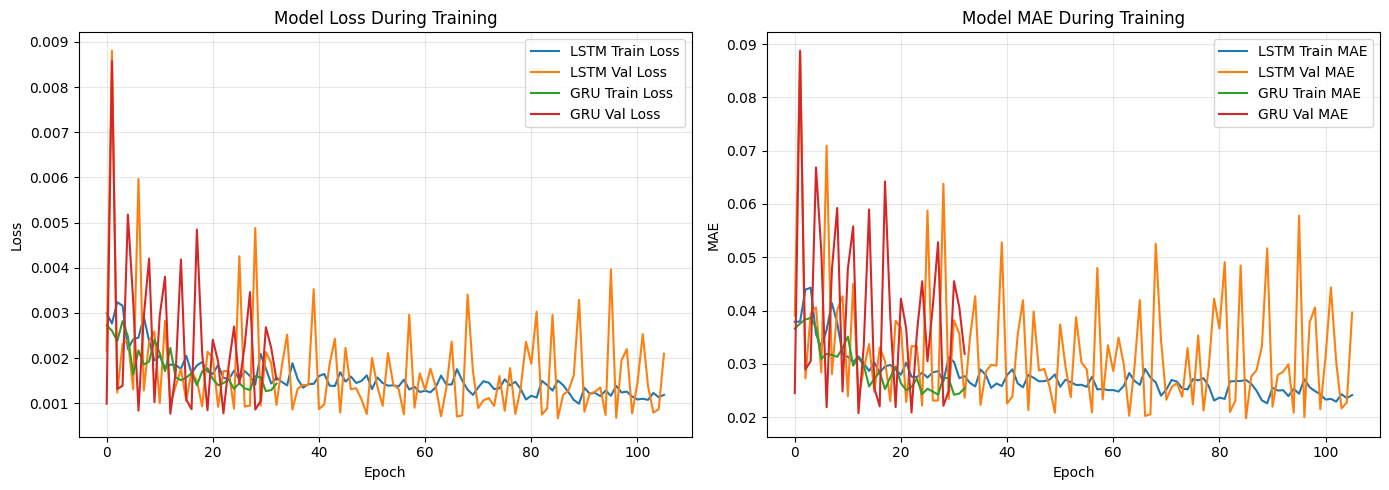

In [44]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(lstm_history.history['loss'], label='LSTM Train Loss')
axes[0].plot(lstm_history.history['val_loss'], label='LSTM Val Loss')
axes[0].plot(gru_history.history['loss'], label='GRU Train Loss')
axes[0].plot(gru_history.history['val_loss'], label='GRU Val Loss')
axes[0].set_title('Model Loss During Training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(lstm_history.history['mae'], label='LSTM Train MAE')
axes[1].plot(lstm_history.history['val_mae'], label='LSTM Val MAE')
axes[1].plot(gru_history.history['mae'], label='GRU Train MAE')
axes[1].plot(gru_history.history['val_mae'], label='GRU Val MAE')
axes[1].set_title('Model MAE During Training')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation

In [45]:
# # Evaluate LSTM model
# from model_lstm import evaluate_lstm_model
# from model_gru import evaluate_gru_model

lstm_results = evaluate_lstm_model(lstm_model, X_test, y_test, target_scaler)
gru_results = evaluate_gru_model(gru_model, X_test, y_test, target_scaler)

print("=" * 50)
print("LSTM Model Evaluation:")
print(f"  RMSE: ${lstm_results['rmse']:.4f}")
print(f"  MAE:  ${lstm_results['mae']:.4f}")
print(f"  R²:   {lstm_results['r2']:.4f}")

print("\n" + "=" * 50)
print("GRU Model Evaluation:")
print(f"  RMSE: ${gru_results['rmse']:.4f}")
print(f"  MAE:  ${gru_results['mae']:.4f}")
print(f"  R²:   {gru_results['r2']:.4f}")

LSTM Model Evaluation:
  RMSE: $29.0761
  MAE:  $22.2937
  R²:   0.8499

GRU Model Evaluation:
  RMSE: $31.2208
  MAE:  $23.4011
  R²:   0.8270


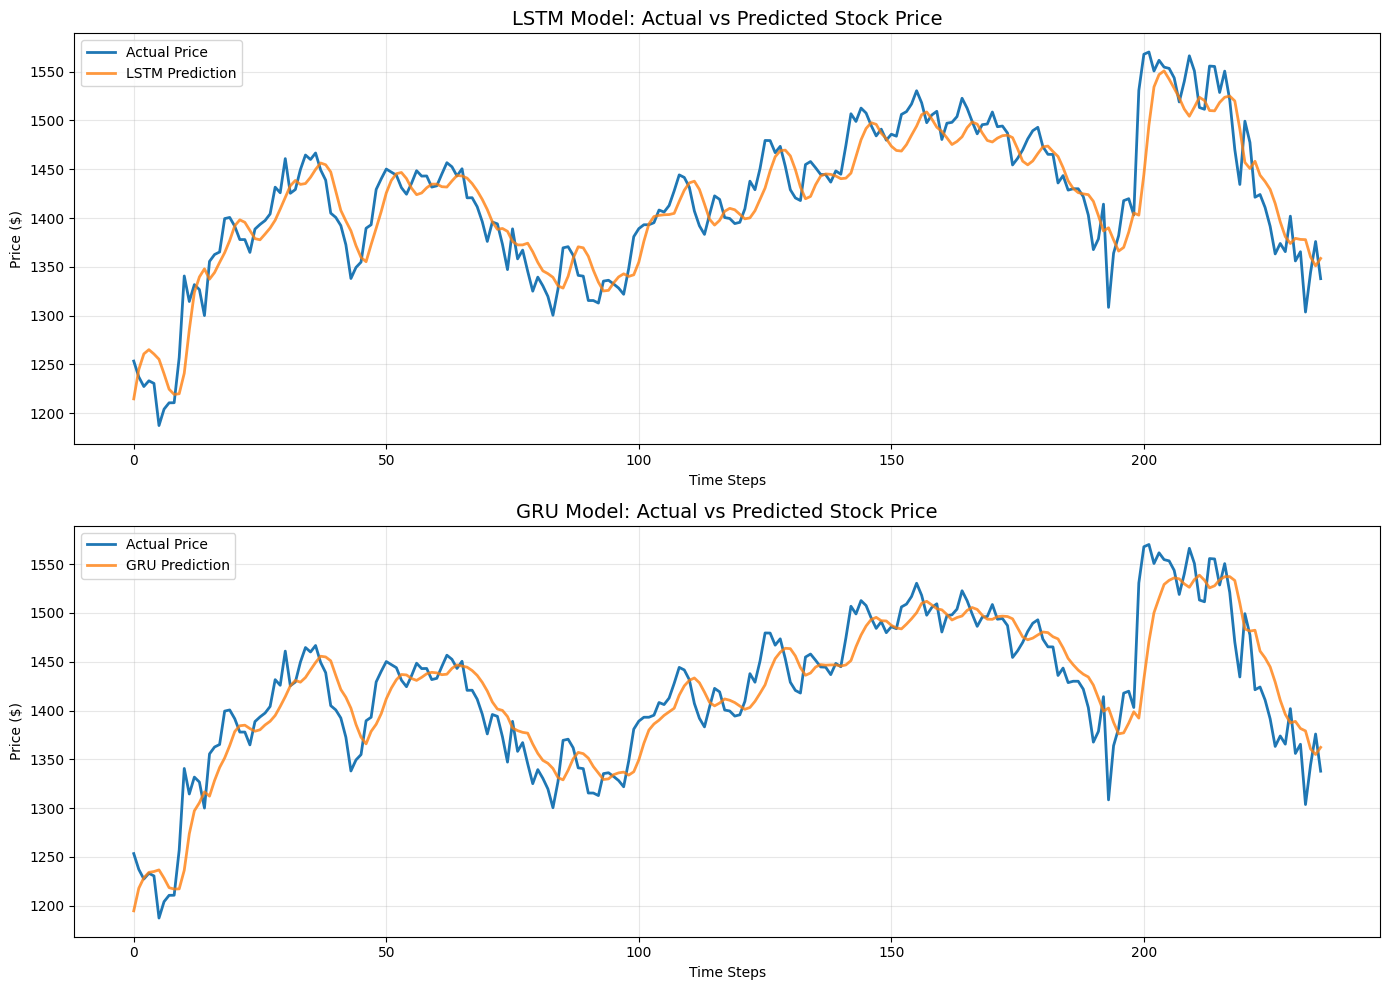

In [46]:
# Plot predictions vs actual
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# LSTM predictions
axes[0].plot(lstm_results['actual'], label='Actual Price', linewidth=2)
axes[0].plot(lstm_results['predictions'], label='LSTM Prediction', linewidth=2, alpha=0.8)
axes[0].set_title('LSTM Model: Actual vs Predicted Stock Price', fontsize=14)
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GRU predictions
axes[1].plot(gru_results['actual'], label='Actual Price', linewidth=2)
axes[1].plot(gru_results['predictions'], label='GRU Prediction', linewidth=2, alpha=0.8)
axes[1].set_title('GRU Model: Actual vs Predicted Stock Price', fontsize=14)
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Price ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison

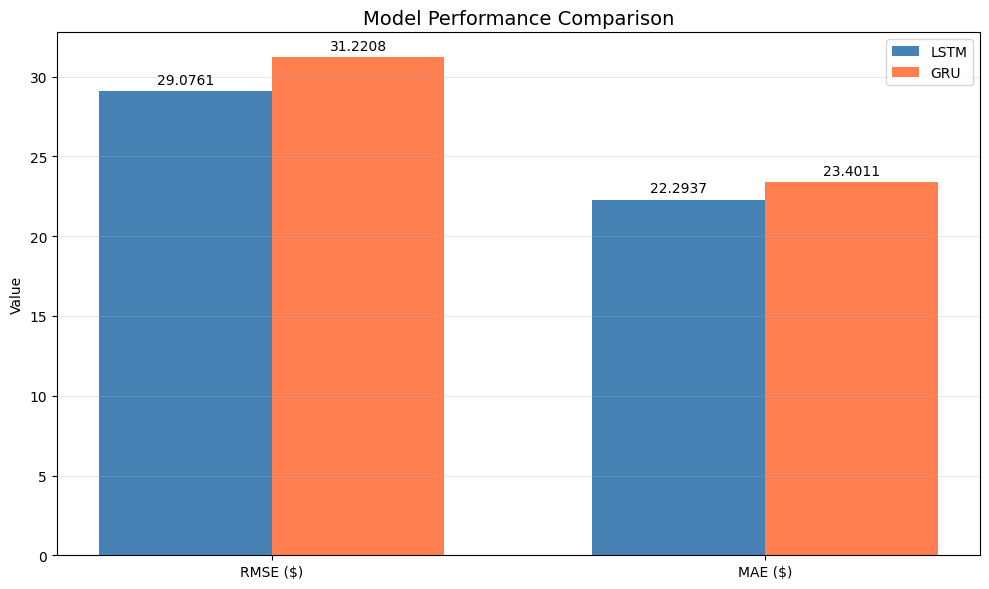

In [47]:
# Compare metrics side by side
metrics = ['RMSE', 'MAE']  # Only plot RMSE and MAE (R² is on different scale)
lstm_values = [lstm_results['rmse'], lstm_results['mae']]
gru_values = [gru_results['rmse'], gru_results['mae']]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lstm_values, width, label='LSTM', color='steelblue')
bars2 = ax.bar(x + width/2, gru_values, width, label='GRU', color='coral')

ax.set_ylabel('Value')
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['RMSE ($)', 'MAE ($)'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

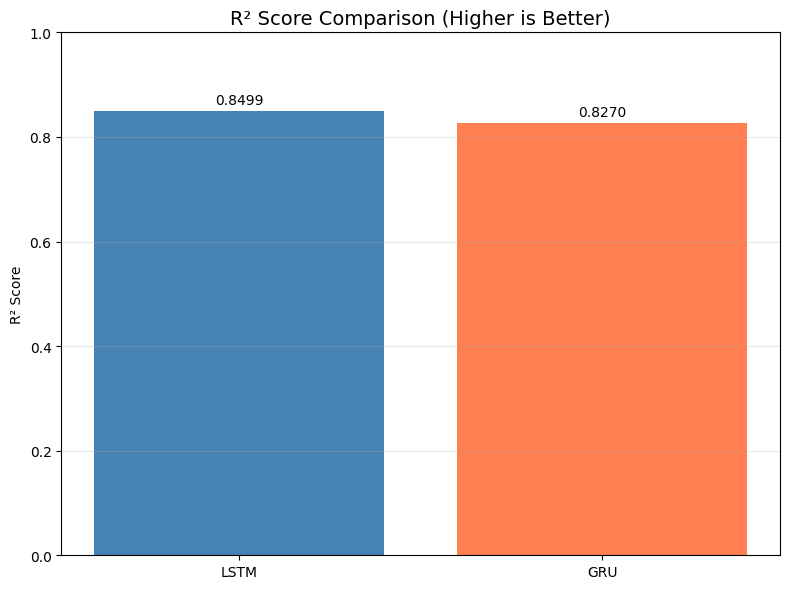

In [48]:
# R² comparison
fig, ax = plt.subplots(figsize=(8, 6))
models = ['LSTM', 'GRU']
r2_scores = [lstm_results['r2'], gru_results['r2']]
colors = ['steelblue', 'coral']

bars = ax.bar(models, r2_scores, color=colors)
ax.set_ylabel('R² Score')
ax.set_title('R² Score Comparison (Higher is Better)', fontsize=14)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Future Price Prediction

Now let's use the trained LSTM model to predict future stock prices.

In [60]:
import numpy as np
import pandas as pd
from datetime import timedelta

# --- STEP 1: GET EVERYTHING READY ---
# We assume 'lstm_model' and 'data' are already loaded from previous steps

# Get the tools we need from the data dictionary
scaler_for_prices = data['target_scaler']   # Tool to convert 0.1 -> $150
length_of_sequence = data['sequence_length'] # Usually 60 days
past_data = data['X_test']                   # All the historical data

# Grab the VERY LAST sequence available (e.g., the last 60 days of history)
# This is our starting point.
current_window = past_data[-1].copy() 

# Prepare an empty list to store our future price guesses
predicted_prices_list = []

# How many days do we want to guess?
days_to_guess = 7

# --- STEP 2: THE GUESSING LOOP ---
# We repeat this process 7 times (once for each day)
for i in range(days_to_guess):
    
    # 1. Prepare the data shape for the model
    # The model expects: (1 batch, 60 time steps, number of features)
    input_for_model = current_window.reshape(1, length_of_sequence, -1)
    
    # 2. Ask the model to predict the next day
    # The result is a small number between 0 and 1 (normalized)
    raw_prediction = lstm_model.predict(input_for_model, verbose=0)
    
    # 3. Convert that small number into a real dollar price
    # Example: 0.75 becomes $150.50
    real_price = scaler_for_prices.inverse_transform(raw_prediction)[0, 0]
    
    # 4. Save the real price to our list
    predicted_prices_list.append(real_price)
    
    # 5. UPDATE THE WINDOW (The Tricky Part)
    # To predict the NEXT day, we need to shift our window forward.
    # We remove the oldest day and add the day we just predicted.
    
    # Grab the last row of our current data
    last_row = current_window[-1].copy()
    
    # Update the 'Close Price' column (index 3) with the NEW prediction.
    # IMPORTANT: We must use the RAW (normalized) prediction here, not the real price,
    # because the rest of the data in 'current_window' is still normalized.
    last_row[3] = raw_prediction[0, 0]
    
    # Shift the window: Take everything EXCEPT the first row, and add the new row at the end
    current_window = np.vstack([current_window[1:], last_row.reshape(1, -1)])

# --- STEP 3: CREATE DATES ---
# We need dates for our predictions (skipping weekends)
today = pd.to_datetime('today')
future_dates = pd.date_range(start=today + timedelta(days=1), 
                             periods=days_to_guess, 
                             freq='B')  # 'B' means Business Days (Mon-Fri)

# --- STEP 4: SHOW THE RESULTS ---
# Put the dates and prices into a table
results_table = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Price': predicted_prices_list
})

print("Here are the predictions for the next 7 days:")
print(results_table.to_string(index=False))

Here are the predictions for the next 7 days:
                      Date  Predicted_Price
2026-03-30 18:23:22.907331      1358.582031
2026-03-31 18:23:22.907331      1367.714844
2026-04-01 18:23:22.907331      1374.745850
2026-04-02 18:23:22.907331      1378.856689
2026-04-03 18:23:22.907331      1380.543945
2026-04-06 18:23:22.907331      1380.658813
2026-04-07 18:23:22.907331      1379.980103


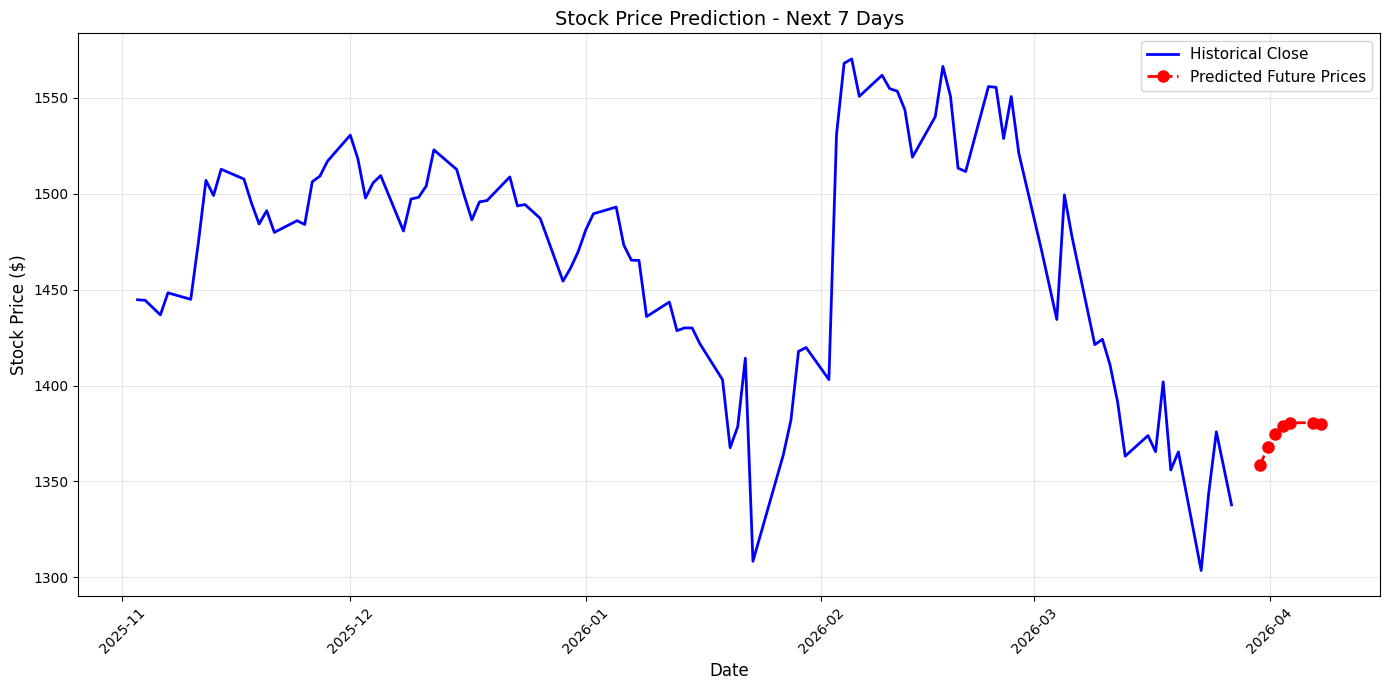


Prediction Summary:
Current Price (last known): $1337.80
Predicted Price (Day 7): $1379.98
Predicted Change: $42.18
Predicted Change %: 3.15%

Average Predicted Price: $1374.44
Min Predicted Price: $1358.58
Max Predicted Price: $1380.66


In [59]:
# Visualize future predictions
plt.figure(figsize=(14, 7))

# Plot historical data (last 100 days for clarity)
historical_close = df_clean['Close'].values[-100:]
historical_dates = df_clean['Date'].values[-100:]
plt.plot(historical_dates, historical_close, 'b-', label='Historical Close', linewidth=2)

# Plot future predictions
plt.plot(future_predictions['Date'], future_predictions['Predicted_Close'], 
         'r--o', label='Predicted Future Prices', linewidth=2, markersize=8)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Stock Price ($)', fontsize=12)
plt.title(f'Stock Price Prediction - Next {DAYS_TO_PREDICT} Days', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nPrediction Summary:")
print("=" * 50)
print(f"Current Price (last known): ${df_clean['Close'].values[-1]:.2f}")
print(f"Predicted Price (Day {DAYS_TO_PREDICT}): ${future_predictions['Predicted_Close'].values[-1]:.2f}")
print(f"Predicted Change: ${future_predictions['Predicted_Close'].values[-1] - df_clean['Close'].values[-1]:.2f}")
print(f"Predicted Change %: {((future_predictions['Predicted_Close'].values[-1] / df_clean['Close'].values[-1]) - 1) * 100:.2f}%")
print(f"\nAverage Predicted Price: ${future_predictions['Predicted_Close'].mean():.2f}")
print(f"Min Predicted Price: ${future_predictions['Predicted_Close'].min():.2f}")
print(f"Max Predicted Price: ${future_predictions['Predicted_Close'].max():.2f}")

In [64]:
data

{'X_train': array([[[0.20807719, 0.1787074 , 0.24572108, 0.20520556, 0.07885625],
         [0.20105904, 0.18037257, 0.24679779, 0.20688947, 0.0671087 ],
         [0.23020806, 0.1997409 , 0.25209855, 0.21422953, 0.12999809],
         ...,
         [0.21509538, 0.21288693, 0.26079521, 0.24488534, 0.26981862],
         [0.21180015, 0.18929352, 0.25343697, 0.22767677, 0.18614764],
         [0.21379467, 0.18399836, 0.25744046, 0.21985051, 0.10461987]],
 
        [[0.20105904, 0.18037257, 0.24679779, 0.20688947, 0.0671087 ],
         [0.23020806, 0.1997409 , 0.25209855, 0.21422953, 0.12999809],
         [0.23537484, 0.20237013, 0.26038106, 0.22998921, 0.13524297],
         ...,
         [0.21180015, 0.18929352, 0.25343697, 0.22767677, 0.18614764],
         [0.21379467, 0.18399836, 0.25744046, 0.21985051, 0.10461987],
         [0.21730664, 0.19366215, 0.26286178, 0.22332887, 0.12239961]],
 
        [[0.23020806, 0.1997409 , 0.25209855, 0.21422953, 0.12999809],
         [0.23537484, 0.20237013

## Summary

This notebook demonstrated:
1. **Data Loading**: Loaded historical stock price data
2. **Preprocessing**: Cleaned and normalized data, created sequences
3. **Model Building**: Created LSTM and GRU architectures
4. **Training**: Trained both models with early stopping
5. **Evaluation**: Compared model performance using RMSE, MAE, and R²

### Key Findings:
- Both LSTM and GRU models can effectively predict stock prices
- The model with higher R² and lower RMSE/MAE performs better
- Early stopping prevents overfitting

### Next Steps:
- Try different hyperparameters (sequence length, layers, units)
- Add more features (volume, technical indicators)
- Implement ensemble methods